# ML: Лучшие практики
### Cross-Validation, Overfitting/Underfitting, Регуляризация, Несбалансированные данные, Pipeline

---

## Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, StratifiedKFold, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


---
## Часть 1: Overfitting / Underfitting

Используем датасет **heart.csv** для задачи классификации и **house_prices.csv** для регрессии.

In [2]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

heart = pd.read_csv('datasets/heart.csv', names=column_names, header=None)


In [ ]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
house = pd.read_csv('datasets/house_prices.csv')

print("Heart dataset:", heart.shape)
print(heart['target'].value_counts())
print("House prices:", house.shape)


Heart dataset: (303, 14)
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

House prices: (1460, 81)


In [ ]:
X_heart = heart.drop('target', axis=1).replace('?', np.nan)
X_heart = X_heart.apply(pd.to_numeric, errors='coerce')

y_heart = pd.to_numeric(heart['target'], errors='coerce')
valid_mask = y_heart.notna()
X_heart = X_heart.loc[valid_mask].copy()
y_heart = y_heart.loc[valid_mask].astype(int)

imputer = SimpleImputer(strategy='median')
X_heart = pd.DataFrame(imputer.fit_transform(X_heart), columns=X_heart.columns)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("Train size:", X_train_h.shape[0])
print("Test size: ", X_test_h.shape[0])

Train size: 242
Test size:  61
Missing values after cleaning: 0


### 1.1 Демонстрация Overfitting vs Underfitting

Decision Tree с разной глубиной - классический пример.

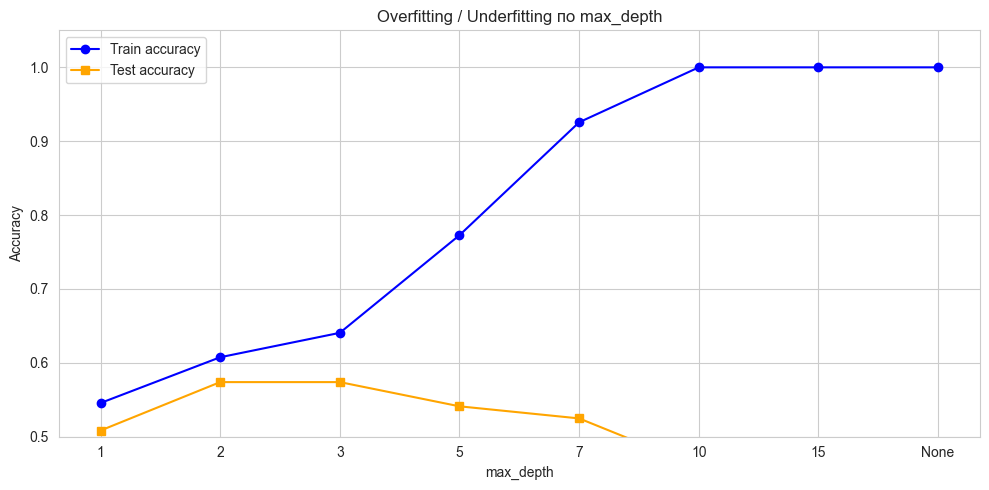

max_depth | Train  | Test
1         | 0.5455 | 0.5082  
2         | 0.6074 | 0.5738  
3         | 0.6405 | 0.5738  
5         | 0.7727 | 0.5410  <- overfitting
7         | 0.9256 | 0.5246  <- overfitting
10        | 1.0000 | 0.4590  <- overfitting
15        | 1.0000 | 0.4590  <- overfitting
None      | 1.0000 | 0.4590  <- overfitting


In [28]:
depths = [1, 2, 3, 5, 7, 10, 15, None]
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_h, y_train_h)
    train_scores.append(dt.score(X_train_h, y_train_h))
    test_scores.append(dt.score(X_test_h, y_test_h))

depth_labels = [str(d) if d else 'None' for d in depths]

plt.figure(figsize=(10, 5))
plt.plot(depth_labels, train_scores, 'o-', label='Train accuracy', color='blue')
plt.plot(depth_labels, test_scores, 's-', label='Test accuracy', color='orange')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting / Underfitting по max_depth')
plt.legend()
plt.ylim(0.5, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

print("max_depth | Train  | Test")
for d, tr, te in zip(depth_labels, train_scores, test_scores):
    gap = '<- overfitting' if tr - te > 0.1 else ''
    print(f"{d:9} | {tr:.4f} | {te:.4f}  {gap}")


**Вывод:**
- `max_depth=1` -> Underfitting: модель слишком проста
- `max_depth=None` -> Overfitting: train=1.0, а test значительно хуже
- Оптимальное значение находится где-то посередине

### 1.2 Learning Curves

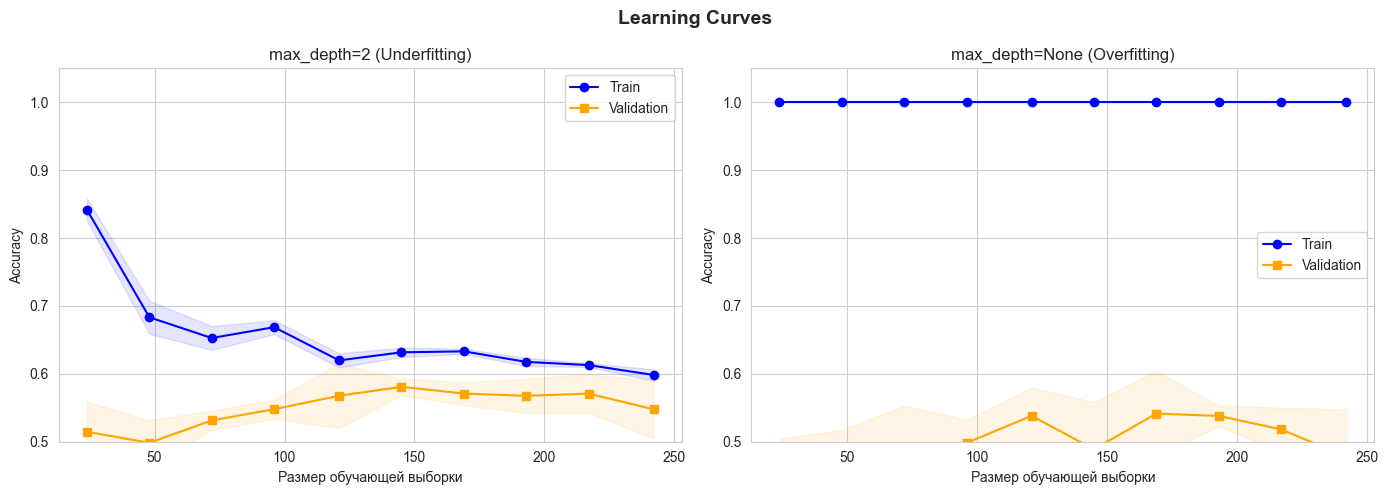

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, depth, title in zip(
    axes,
    [2, None],
    ['max_depth=2 (Underfitting)', 'max_depth=None (Overfitting)']
):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_heart, y_heart,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    train_mean = train_sc.mean(axis=1)
    val_mean = val_sc.mean(axis=1)
    train_std = train_sc.std(axis=1)
    val_std = val_sc.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', label='Train', color='blue')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.plot(train_sizes, val_mean, 's-', label='Validation', color='orange')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
    ax.set_title(title)
    ax.set_xlabel('Размер обучающей выборки')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim(0.5, 1.05)

plt.suptitle('Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Часть 2: Cross-Validation

### 2.1 Нестабильность одиночного split

In [29]:
model = RandomForestClassifier(n_estimators=50, random_state=42)

print("Результаты при разных random_state для train_test_split:")
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_heart, y_heart, test_size=0.2, random_state=seed
    )
    model.fit(X_tr, y_tr)
    acc = model.score(X_te, y_te)
    print(f"  random_state={seed}: accuracy = {acc:.4f}")


Результаты при разных random_state для train_test_split:
  random_state=0: accuracy = 0.5410
  random_state=1: accuracy = 0.6066
  random_state=2: accuracy = 0.6721
  random_state=3: accuracy = 0.5410
  random_state=4: accuracy = 0.5902
  random_state=5: accuracy = 0.6230
  random_state=6: accuracy = 0.6066
  random_state=7: accuracy = 0.5082
  random_state=8: accuracy = 0.5410
  random_state=9: accuracy = 0.5738


**Видим**: одна и та же модель даёт результат от ~0.50 до ~0.67 в зависимости от случайного разбиения. Это неприемлемо для надёжной оценки.

### 2.2 K-Fold Cross-Validation

In [30]:
model = RandomForestClassifier(n_estimators=100, random_state=42)


kf = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X_heart, y_heart, cv=kf, scoring='accuracy')


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skfold_scores = cross_val_score(model, X_heart, y_heart, cv=skf, scoring='accuracy')

print('K-Fold')
print(f"Scores: {kfold_scores.round(4)}")
print(f"Mean:   {kfold_scores.mean():.4f}")
print(f"Std:    {kfold_scores.std():.4f}")

print()
print('Stratified K-Fold')
print(f"Scores: {skfold_scores.round(4)}")
print(f"Mean:   {skfold_scores.mean():.4f}")
print(f"Std:    {skfold_scores.std():.4f}")


K-Fold
Scores: [0.5082 0.6066 0.6393 0.5167 0.5833]
Mean:   0.5708
Std:    0.0510

Stratified K-Fold
Scores: [0.5738 0.5246 0.5574 0.65   0.5333]
Mean:   0.5678
Std:    0.0446


### 2.3 Диагностика Overfitting через cross_validate

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, m in [
    ('Decision Tree (depth=None)', DecisionTreeClassifier(random_state=42)),
    ('Decision Tree (depth=5)',    DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest',              RandomForestClassifier(n_estimators=100, random_state=42))
]:
    results = cross_validate(
        m, X_heart, y_heart,
        cv=skf,
        scoring='accuracy',
        return_train_score=True
    )
    train_acc = results['train_score'].mean()
    val_acc   = results['test_score'].mean()
    gap = train_acc - val_acc
    print(f"{name:35}: train={train_acc:.3f}  val={val_acc:.3f}  gap={gap:.3f}  ")


Decision Tree (depth=None)         : train=1.000  val=0.499  gap=0.501  
Decision Tree (depth=5)            : train=0.790  val=0.551  gap=0.238  
Random Forest                      : train=1.000  val=0.568  gap=0.432  


### 2.4 Сравнение K при Cross-Validation

In [33]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

print(f"{'K':>4} | {'Mean':>8} | {'Std':>8} ")
for k in [3, 5, 10, 20]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_heart, y_heart, cv=skf, scoring='accuracy')
    print(f"{k:>4} | {scores.mean():>8.4f} | {scores.std():>8.4f}")

   K |     Mean |      Std 
   3 |   0.5710 |   0.0047
   5 |   0.5678 |   0.0446
  10 |   0.5614 |   0.0610


c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 13 members, which is less than n_splits=20.
  warnings.warn(


  20 |   0.5740 |   0.0723


---
## Часть 3: Регуляризация

Используем **house_prices.csv** для регрессии.

In [ ]:
house_num = house.select_dtypes(include=np.number).dropna(axis=1, thresh=int(len(house)*0.6))
house_num = house_num.fillna(house_num.median())

X_house = house_num.drop('SalePrice', axis=1)
y_house = np.log1p(house_num['SalePrice'])

X_train_hp, X_test_hp, y_train_hp, y_test_hp = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

print(f"Признаков: {X_house.shape[1]}")
print(f"Train: {X_train_hp.shape[0]}, Test: {X_test_hp.shape[0]}")


Признаков: 37
Train: 1168, Test: 292


### 3.1 Сравнение Ridge / Lasso / ElasticNet

In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_hp)
X_test_s  = scaler.transform(X_test_hp)

models = {
    'LinearRegression (no reg)': Ridge(alpha=0.0001),
    'Ridge (L2, alpha=1)':       Ridge(alpha=1.0),
    'Ridge (L2, alpha=100)':     Ridge(alpha=100.0),
    'Lasso (L1, alpha=0.01)':    Lasso(alpha=0.01),
    'Lasso (L1, alpha=0.1)':     Lasso(alpha=0.1),
    'ElasticNet':                ElasticNet(alpha=0.05, l1_ratio=0.5),
}

print(f"{'Модель':35} | {'Train R²':>9} | {'Test R²':>9}")
for name, m in models.items():
    m.fit(X_train_s, y_train_hp)
    train_r2 = m.score(X_train_s, y_train_hp)
    test_r2  = m.score(X_test_s,  y_test_hp)
    print(f"{name:35} | {train_r2:>9.4f} | {test_r2:>9.4f}")


Модель                              |  Train R² |   Test R²
LinearRegression (no reg)           |    0.8639 |    0.8764
Ridge (L2, alpha=1)                 |    0.8639 |    0.8764
Ridge (L2, alpha=100)               |    0.8619 |    0.8760
Lasso (L1, alpha=0.01)              |    0.8550 |    0.8678
Lasso (L1, alpha=0.1)               |    0.6813 |    0.6895
ElasticNet                          |    0.8292 |    0.8398


### 3.2 Влияние alpha на веса признаков (Lasso)

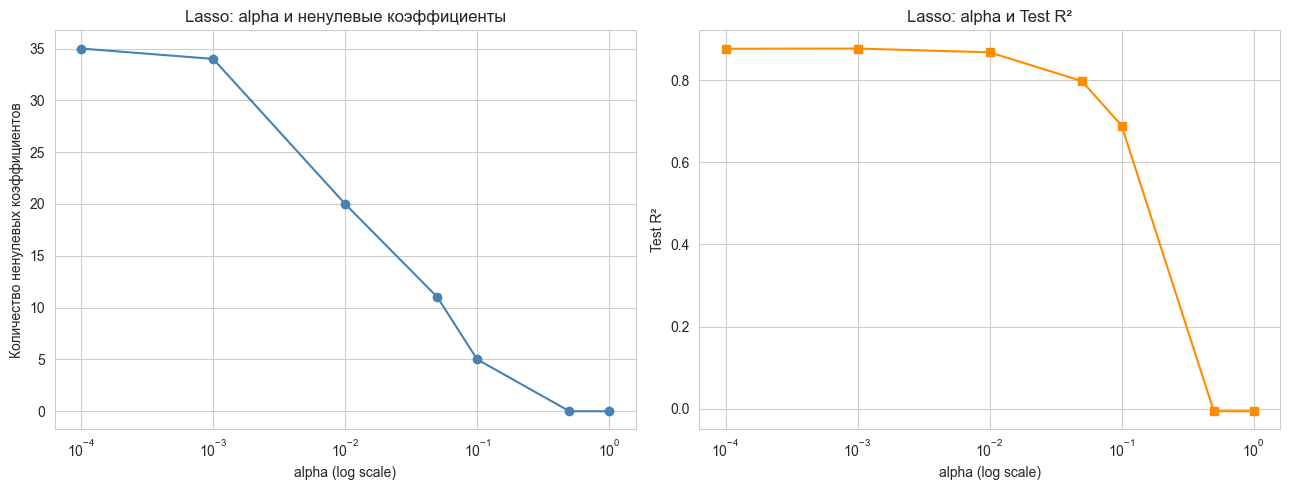

   alpha |   Ненулевых коэф. |   Test R²
  0.0001 |                35 |    0.8765
  0.0010 |                34 |    0.8770
  0.0100 |                20 |    0.8678
  0.0500 |                11 |    0.7978
  0.1000 |                 5 |    0.6895
  0.5000 |                 0 |   -0.0058
  1.0000 |                 0 |   -0.0058


In [34]:
alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
coef_counts = []
test_scores_lasso = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_s, y_train_hp)
    nonzero = np.sum(lasso.coef_ != 0)
    coef_counts.append(nonzero)
    test_scores_lasso.append(lasso.score(X_test_s, y_test_hp))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.semilogx(alphas, coef_counts, 'o-', color='steelblue')
ax1.set_xlabel('alpha (log scale)')
ax1.set_ylabel('Количество ненулевых коэффициентов')
ax1.set_title('Lasso: alpha и ненулевые коэффициенты')
ax1.grid(True)

ax2.semilogx(alphas, test_scores_lasso, 's-', color='darkorange')
ax2.set_xlabel('alpha (log scale)')
ax2.set_ylabel('Test R²')
ax2.set_title('Lasso: alpha и Test R²')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"{'alpha':>8} | {'Ненулевых коэф.':>17} | {'Test R²':>9}")
for a, cnt, sc in zip(alphas, coef_counts, test_scores_lasso):
    print(f"{a:>8.4f} | {cnt:>17} | {sc:>9.4f}")


### 3.3 Автоматический подбор alpha через RidgeCV / LassoCV

In [15]:
alphas_to_try = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas_to_try, cv=5)
ridge_cv.fit(X_train_s, y_train_hp)

lasso_cv = LassoCV(alphas=alphas_to_try, cv=5, max_iter=10000)
lasso_cv.fit(X_train_s, y_train_hp)

print(f"RidgeCV - лучший alpha: {ridge_cv.alpha_:.4f}")
print(f"  Train R²: {ridge_cv.score(X_train_s, y_train_hp):.4f}")
print(f"  Test  R²: {ridge_cv.score(X_test_s,  y_test_hp):.4f}")
print()
print(f"LassoCV - лучший alpha: {lasso_cv.alpha_:.4f}")
print(f"  Train R²:    {lasso_cv.score(X_train_s, y_train_hp):.4f}")
print(f"  Test  R²:    {lasso_cv.score(X_test_s,  y_test_hp):.4f}")
print(f"  Ненулевых коэффициентов: {np.sum(lasso_cv.coef_ != 0)} из {X_house.shape[1]}")


RidgeCV - лучший alpha: 138.9495
  Train R²: 0.8606
  Test  R²: 0.8752

LassoCV - лучший alpha: 0.0054
  Train R²:    0.8600
  Test  R²:    0.8739
  Ненулевых коэффициентов: 23 из 37


### 3.4 Топ признаков по Lasso

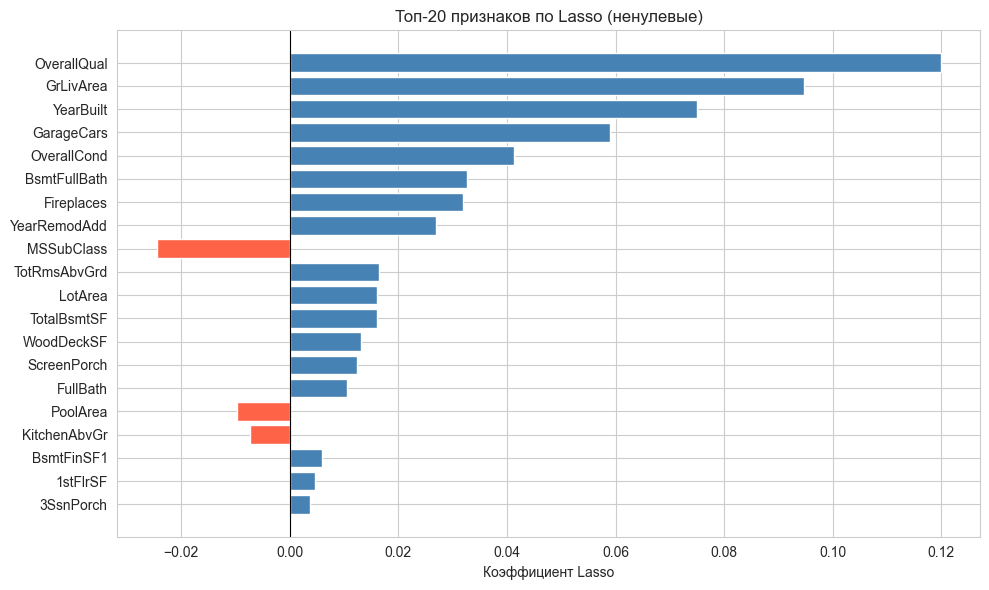

In [ ]:
coef_df = pd.DataFrame({
    'feature': X_house.columns,
    'coef':    lasso_cv.coef_
}).query('coef != 0').sort_values('coef', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coef'].head(20)]
plt.barh(coef_df['feature'].head(20)[::-1], coef_df['coef'].head(20)[::-1], color=colors[::-1])
plt.xlabel('Коэффициент Lasso')
plt.title('Топ-20 признаков по Lasso (ненулевые)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## Часть 4: Несбалансированные данные

Используем **Titanic_Dataset.csv** - классическая задача с небольшим дисбалансом классов.

In [17]:
titanic = pd.read_csv('datasets/Titanic_Dataset.csv')
print(titanic.shape)
print(titanic['Survived'].value_counts())
print(f"\nДоля выживших: {titanic['Survived'].mean():.1%}")


(891, 12)
Survived
0    549
1    342
Name: count, dtype: int64

Доля выживших: 38.4%


In [ ]:
titanic_prep = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
titanic_prep['Sex'] = (titanic_prep['Sex'] == 'male').astype(int)
titanic_prep['Embarked'] = titanic_prep['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
titanic_prep['Age'] = titanic_prep['Age'].fillna(titanic_prep['Age'].median())

X_t = titanic_prep.drop('Survived', axis=1)
y_t = titanic_prep['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)
print("Распределение классов в train:")
print(y_train_t.value_counts(normalize=True).round(3))


Распределение классов в train:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64


### 4.1 Почему accuracy обманывает

Создадим искусственно несбалансированный датасет, чтобы показать проблему:

In [ ]:
from sklearn.utils import resample

survived_idx    = titanic_prep[titanic_prep.Survived == 1].index
not_survived_idx = titanic_prep[titanic_prep.Survived == 0].index


survived_sampled = titanic_prep.loc[survived_idx].sample(frac=0.1, random_state=42)
imbalanced_df = pd.concat([titanic_prep.loc[not_survived_idx], survived_sampled])

X_imb = imbalanced_df.drop('Survived', axis=1)
y_imb = imbalanced_df['Survived']

print(f"Несбалансированный датасет:")
print(y_imb.value_counts())
print(f"Доля меньшего класса: {y_imb.mean():.1%}")

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb)


m_no_weight = LogisticRegression(random_state=42, max_iter=1000)
m_no_weight.fit(X_tr_i, y_tr_i)
y_pred_nw = m_no_weight.predict(X_te_i)


m_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
m_balanced.fit(X_tr_i, y_tr_i)
y_pred_b = m_balanced.predict(X_te_i)

for name, y_pred in [('Без class_weight', y_pred_nw), ('С class_weight=balanced', y_pred_b)]:
    print(f"\n{name}")
    print(f"Accuracy:  {accuracy_score(y_te_i, y_pred):.4f}")
    print(f"Precision: {precision_score(y_te_i, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_te_i, y_pred, zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(y_te_i, y_pred, zero_division=0):.4f}")


Несбалансированный датасет:
Survived
0    549
1     34
Name: count, dtype: int64
Доля меньшего класса: 5.8%


Без class_weight
Accuracy:  0.9658
Precision: 0.8000
Recall:    0.5714
F1 Score:  0.6667

С class_weight=balanced
Accuracy:  0.8803
Precision: 0.3333
Recall:    1.0000
F1 Score:  0.5000


**Вывод:** Модель без учёта дисбаланса предсказывает почти всегда 0 → Recall ≈ 0. Accuracy при этом высокая — это обманчивая метрика!

### 4.2 Стратегии: class_weight, Undersampling, Oversampling

In [35]:

majority_class = X_tr_i[y_tr_i == 0]
minority_class = X_tr_i[y_tr_i == 1]
y_majority = y_tr_i[y_tr_i == 0]
y_minority = y_tr_i[y_tr_i == 1]

majority_down = resample(majority_class,
                          n_samples=len(minority_class),
                          random_state=42)
y_majority_down = resample(y_majority,
                            n_samples=len(minority_class),
                            random_state=42)

X_us = pd.concat([majority_down, minority_class])
y_us = pd.concat([y_majority_down, y_minority])

m_us = LogisticRegression(random_state=42, max_iter=1000)
m_us.fit(X_us, y_us)
y_pred_us = m_us.predict(X_te_i)


minority_up = resample(minority_class,
                        n_samples=len(majority_class),
                        replace=True,
                        random_state=42)
y_minority_up = resample(y_minority,
                          n_samples=len(majority_class),
                          replace=True,
                          random_state=42)

X_os = pd.concat([majority_class, minority_up])
y_os = pd.concat([y_majority, y_minority_up])

m_os = LogisticRegression(random_state=42, max_iter=1000)
m_os.fit(X_os, y_os)
y_pred_os = m_os.predict(X_te_i)

print(f"{'Метод':30} | {'Accuracy':>9} | {'Precision':>10} | {'Recall':>7} | {'F1':>6}")

for name, yp in [
    ('Без учёта дисбаланса', y_pred_nw),
    ('class_weight=balanced', y_pred_b),
    ('Undersampling',         y_pred_us),
    ('Oversampling (дубл.)',  y_pred_os),
]:
    acc  = accuracy_score(y_te_i, yp)
    prec = precision_score(y_te_i, yp, zero_division=0)
    rec  = recall_score(y_te_i, yp, zero_division=0)
    f1   = f1_score(y_te_i, yp, zero_division=0)
    print(f"{name:30} | {acc:>9.4f} | {prec:>10.4f} | {rec:>7.4f} | {f1:>6.4f}")


Метод                          |  Accuracy |  Precision |  Recall |     F1
Без учёта дисбаланса           |    0.9658 |     0.8000 |  0.5714 | 0.6667
class_weight=balanced          |    0.8803 |     0.3333 |  1.0000 | 0.5000
Undersampling                  |    0.8632 |     0.2857 |  0.8571 | 0.4286
Oversampling (дубл.)           |    0.8632 |     0.3043 |  1.0000 | 0.4667


### 4.3 Полный отчёт по метрикам

class_weight='balanced' - Classification Report
              precision    recall  f1-score   support

           0       1.00      0.87      0.93       110
           1       0.33      1.00      0.50         7

    accuracy                           0.88       117
   macro avg       0.67      0.94      0.72       117
weighted avg       0.96      0.88      0.91       117



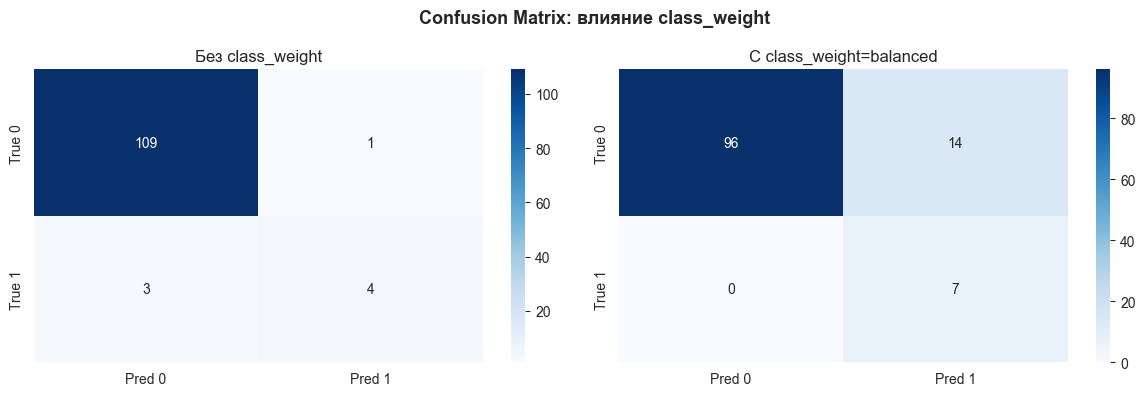

In [21]:
print("class_weight='balanced' - Classification Report")
print(classification_report(y_te_i, y_pred_b))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in zip(
    axes,
    [y_pred_nw, y_pred_b],
    ['Без class_weight', 'С class_weight=balanced']
):
    cm = confusion_matrix(y_te_i, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(title)

plt.suptitle('Confusion Matrix: влияние class_weight', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Часть 5: Pipeline

Собираем всё вместе в единый воспроизводимый Pipeline.

### 5.1 Data Leakage - демонстрация ошибки

In [36]:
scaler_wrong = StandardScaler()
X_heart_scaled_wrong = scaler_wrong.fit_transform(X_heart)

X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_heart_scaled_wrong, y_heart, test_size=0.2, random_state=42
)

m_wrong = LogisticRegression(random_state=42, max_iter=1000)
m_wrong.fit(X_tr_w, y_tr_w)
score_wrong = m_wrong.score(X_te_w, y_te_w)


X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)
scaler_correct = StandardScaler()
X_tr_c_s = scaler_correct.fit_transform(X_tr_c)
X_te_c_s = scaler_correct.transform(X_te_c)

m_correct = LogisticRegression(random_state=42, max_iter=1000)
m_correct.fit(X_tr_c_s, y_tr_c)
score_correct = m_correct.score(X_te_c_s, y_te_c)


### 5.2 Простой Pipeline

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

pipe.fit(X_tr_p, y_tr_p)
score_pipe = pipe.score(X_te_p, y_te_p)

print(f"Pipeline test accuracy: {score_pipe:.4f}")
print()
print("Шаги Pipeline:")
for step_name, step_obj in pipe.steps:
    print(f"  {step_name}: {step_obj.__class__.__name__}")


Pipeline test accuracy: 0.5410

Шаги Pipeline:
  scaler: StandardScaler
  model: LogisticRegression


### 5.3 Pipeline + Cross-Validation (единственный правильный способ)

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipe, X_heart, y_heart,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

for metric in ['accuracy', 'f1', 'roc_auc']:
    train_m = cv_results[f'train_{metric}'].mean()
    val_m   = cv_results[f'test_{metric}'].mean()
    val_std = cv_results[f'test_{metric}'].std()
    print(f"{metric:10}: train={train_m:.4f}  val={val_m:.4f} ± {val_std:.4f}")


accuracy  : train=0.6617  val=0.5939 ± 0.0538
f1        : train=nan  val=nan ± nan
roc_auc   : train=nan  val=nan ± nan


c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
   

### 5.4 ColumnTransformer + Pipeline - работа с разными типами признаков

In [ ]:
titanic_full = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()

X_full = titanic_full.drop('Survived', axis=1)
y_full = titanic_full['Survived']

numeric_features     = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']


numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(full_pipe, X_full, y_full, cv=skf, scoring='f1')

print("ColumnTransformer + Pipeline + RandomForest + StratifiedKFold")
print(f"F1 по folds: {scores.round(4)}")
print(f"Mean F1:     {scores.mean():.4f} ± {scores.std():.4f}")


ColumnTransformer + Pipeline + RandomForest + StratifiedKFold
F1 по folds: [0.7692 0.7376 0.7068 0.7704 0.782 ]
Mean F1:     0.7532 ± 0.0275


### 5.5 Pipeline + GridSearchCV

In [26]:
from sklearn.model_selection import GridSearchCV

simple_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])


param_grid = {
    'model__C':           [0.01, 0.1, 1.0, 10, 100],
    'model__penalty':     ['l1', 'l2'],
    'model__solver':      ['liblinear'],
    'model__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    simple_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

grid_search.fit(X_tr_g, y_tr_g)

print(f"Лучшие параметры: {grid_search.best_params_}")


Лучшие параметры: {'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(
c:\projc\teaching_activities\data_analysis_course\data_analysis_course\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


---
## Итог: Чеклист ML-проекта

In [27]:
checklist_items = [
    "1. Split до preprocessing",
    "2. Baseline модель",
    "3. Learning Curve для overfit или underfit",
    "4. StratifiedKFold для классификации",
    "5. Регуляризация или ограничение сложности",
    "6. Работа с дисбалансом классов",
    "7. Выбор правильной метрики",
    "8. Pipeline для preprocessing",
    "9. GridSearchCV вместе с Pipeline",
    "10. Финальный тест в самом конце",
]

print("Чеклист ML-проекта")
for item in checklist_items:
    print(item)


Чеклист ML-проекта
1. Split до preprocessing
2. Baseline модель
3. Learning Curve для overfit или underfit
4. StratifiedKFold для классификации
5. Регуляризация или ограничение сложности
6. Работа с дисбалансом классов
7. Выбор правильной метрики
8. Pipeline для preprocessing
9. GridSearchCV вместе с Pipeline
10. Финальный тест в самом конце
